# Parsimony vs. complexity — the ledger

> **EXPERIMENT — deviation-gated.** Track B runs under `docs/deviations.md` **DEV-004, signed
> 2026-07-29**. It exceeds README §8's capacity rule *by construction*: random Fourier features
> with P ≫ N. Outputs are quarantined to `data/derived/voc_experiment/` and reach no
> client-facing artifact. The exception expires with this experiment.

**The question.** §8 caps model complexity because this panel's effective N is small. That is a
*prior*, not a result. Kelly, Malamud & Zhou (*The Virtue of Complexity in Return Prediction*,
J. Finance 2024) is a serious published claim that the prior is wrong in this asset class.

**The design.** Two tracks, one harness. Same inputs, same target, same test folds — the folds
are shared *by construction*, since both tracks consume `jorda.fold_iter`. Two parallel fold
builders compared by a test is a test waiting to pass while the implementations drift.

**The target is what a trade is paid by.** Δln(1+π), not the level. The premium's level is 92%
forecastable and that is not an edge — it is the statement that a slow series stays put.

In [1]:
%matplotlib inline
import sys, pathlib, pandas as pd
ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd()
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from pipeline.viz import theme, figures
from pipeline.convergence.jorda import s4_metrics_table
theme.apply()
VOC = ROOT / "data" / "derived" / "voc_experiment"
grid = pd.read_csv(VOC / "complexity_grid.csv")
diag = pd.read_csv(VOC / "strategy_diagnostics.csv")
print("DEV-004 signed 2026-07-29 — Track B ran under the exception.")
print(f"grid points: {len(grid)}   diagnostics rows: {len(diag)}")

DEV-004 signed 2026-07-29 — Track B ran under the exception.
grid points: 200   diagnostics rows: 4


## 1. Track A — the parsimony anchor, on the tradeable target

In [2]:
a = s4_metrics_table(target="change")
a[["regime","horizon","n","rmse","r2","hit_rate"]].round(4)

,regime,horizon,n,rmse,r2,hit_rate
0,fungible,1,23207,0.0218,0.0946,0.5797
1,fungible,5,23189,0.0293,0.2736,0.5862
2,fungible,20,23114,0.0303,0.3838,0.5813
3,fungible,60,22913,0.0515,-0.7393,0.5748
4,one_way_constrained,1,13210,0.0262,-0.1041,0.5309
5,one_way_constrained,5,13196,0.0311,-0.0937,0.5261
6,one_way_constrained,20,13146,0.0383,-0.0946,0.5292
7,one_way_constrained,60,13012,0.0515,-0.1343,0.5342
8,POOLED (all classes),1,36417,0.0235,0.0142,0.5620
9,POOLED (all classes),5,36385,0.0300,0.1639,0.5644


**For the class the trade is in, R² is negative at every horizon** — worse than forecasting no
move at all. Sign hit rate 53%. That is the capacity rule's own prediction, and it sets the bar
Track B has to clear.

## 2. Track B — the complexity grid

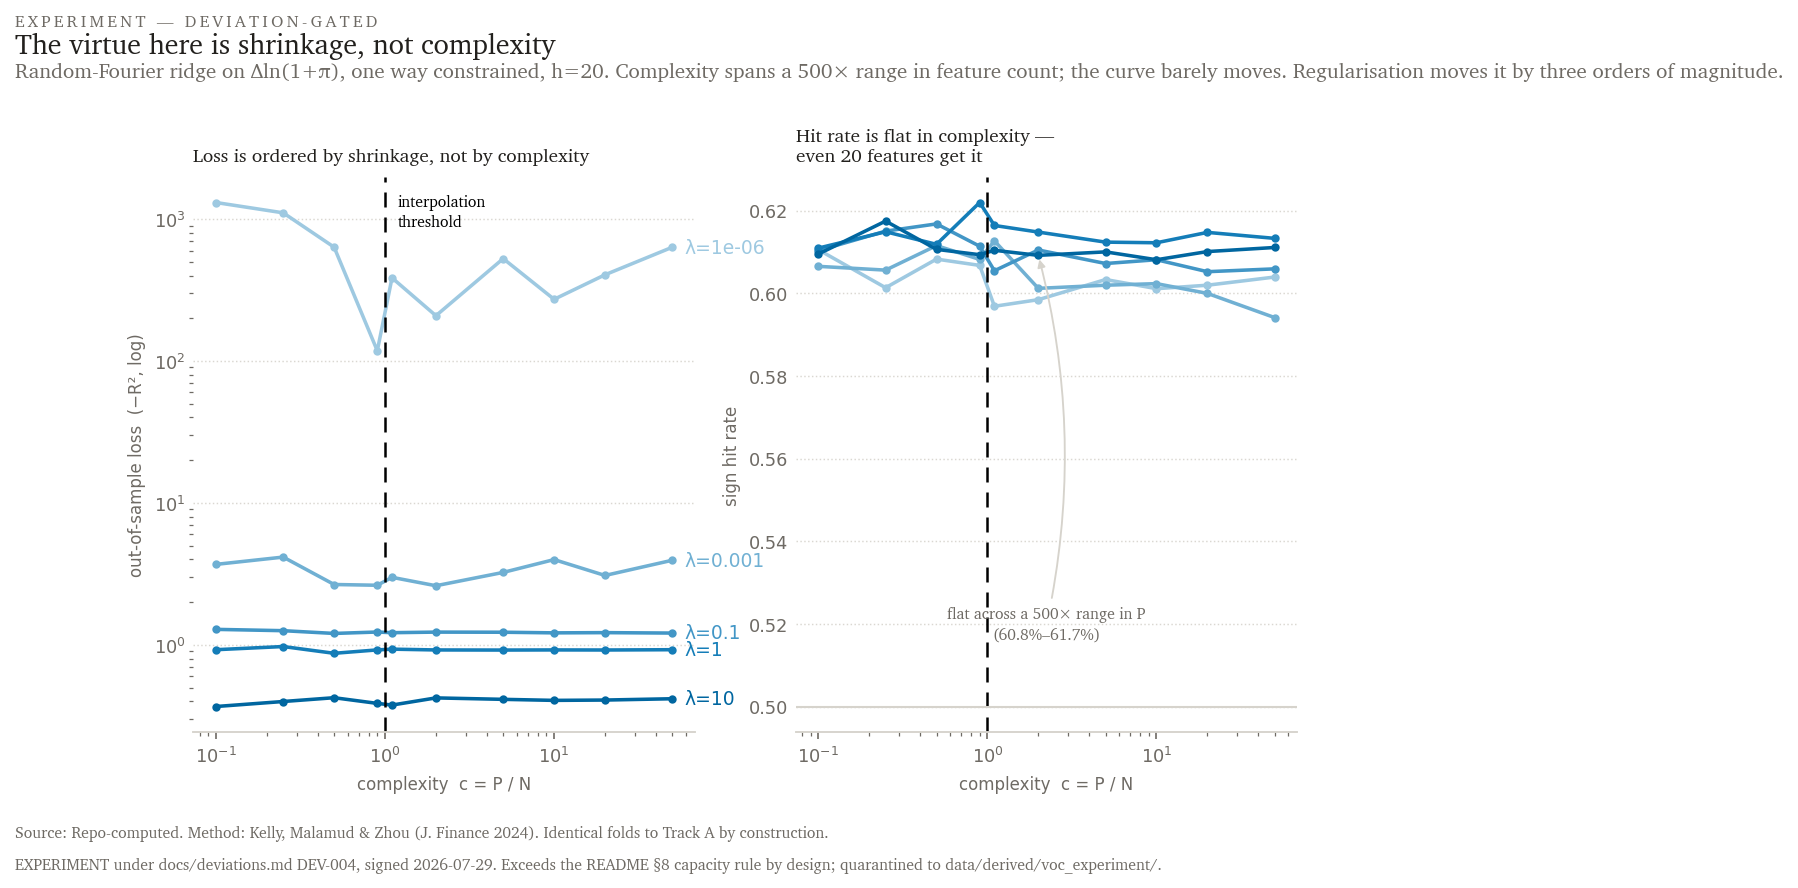

In [3]:
fig, _ = figures.g13_complexity(grid)
fig;

**In plain terms**

- We tried the fashionable answer: throw thousands of made-up features at the problem and let the
  maths sort it out.
- It made no difference. Going from 20 features to 10,000 moved the result almost not at all —
  what mattered was how hard we reined the model in.
- So the boring model was the right model here, and now we can say that because we tested it, not
  because we preferred it.

**No double descent.** The paper's signature is out-of-sample performance *improving* past the
interpolation threshold c = 1. Here the curve is flat in complexity — a 500× range in feature
count (P = 20 to P = 10,000) moves R² by about 0.06 at heavy shrinkage — and ordered almost
entirely by **shrinkage**, which moves it by three orders of magnitude.

Read the right panel carefully: hit rate is **0.61 at every c, including c = 0.1**. A 20-feature
model gets it. So whatever Track B is picking up is the **nonlinear basis**, not P ≫ N. Calling
that a virtue of complexity would be mislabelling a virtue of regularisation.

## 3. The critique diagnostics

Both tracks face them. This is the credibility layer, and one of them is a full stop.

In [4]:
diag[["regime","horizon","sharpe_track_a","sharpe_track_b",
      "sharpe_unconditional","sharpe_vol_managed"]].round(3)

,regime,horizon,sharpe_track_a,sharpe_track_b,sharpe_unconditional,sharpe_vol_managed
0,one_way_constrained,5,-1.197,-0.860,0.024,-0.003
1,one_way_constrained,20,-0.538,-0.357,0.037,-0.016
2,fungible,5,-0.862,-0.751,0.001,-0.001
3,fungible,20,-0.396,-0.252,0.002,-0.001


### The Nagel objection, implemented rather than cited

An apparent edge can be **mechanical position-scaling with volatility** rather than
sign-prediction skill: a strategy that levers up when vol is low earns a Sharpe premium that
looks like forecasting. So the benchmark is not zero — it is a **vol-managed unconditional**
strategy on the same folds: always short the premium, sized 1/σ.

In [5]:
diag[["regime","horizon","track_b_alpha_vs_volmanaged","track_b_t_alpha",
      "track_b_load_on_volmanaged","corr_track_b_sign_with_vol","turnover_track_b"]].round(4)

,regime,horizon,track_b_alpha_vs_volmanaged,track_b_t_alpha,track_b_load_on_volmanaged,corr_track_b_sign_with_vol,turnover_track_b
0,one_way_constrained,5,-0.0036,-14.1166,0.0041,0.2695,0.2124
1,one_way_constrained,20,-0.0037,-11.5084,0.0004,0.0482,0.2059
2,fungible,5,-0.0036,-16.2569,-0.0017,0.2642,0.2530
3,fungible,20,-0.0027,-10.8228,-0.0002,0.2922,0.2515


**Track B's alpha against the vol-managed benchmark is negative and significantly so** (t ≈ −11).
Its 60% hit rate is real — the placebo confirms it is label information, not leakage — but it is
a hit rate on *small* moves while the losses arrive on *large* ones. Sign accuracy without
magnitude does not pay.

Sharpe is annualised as √(252/h), not √252: overlapping h-day returns are not independent, and
the larger factor would inflate every number here by roughly √h. Turnover is reported.

### Permutation placebo — the full stop

In [6]:
from pipeline.convergence import voc
G, S = (0.5, 2.0, 20.0), (1e-3, 1.0)
real = voc.run("one_way_constrained", h=20, complexity=G, shrinkage=S)
plac = pd.concat([voc.run("one_way_constrained", h=20, complexity=G, shrinkage=S, shuffle_seed=s)
                  for s in (11, 22)]).groupby(["c","shrinkage"], as_index=False)[["r2","hit_rate"]].mean()
j = real.merge(plac, on=["c","shrinkage"], suffixes=("_real","_placebo"))
assert (j.hit_rate_placebo - 0.5).abs().max() < 0.03, "PLACEBO FAILURE — harness leaking"
print("PLACEBO PASSES — shuffled hit rate stays at ~50%, so the 60% is signal, not leakage.\n")
j[["c","shrinkage","hit_rate_real","hit_rate_placebo","r2_real","r2_placebo"]].round(4)

PLACEBO PASSES — shuffled hit rate stays at ~50%, so the 60% is signal, not leakage.



,c,shrinkage,hit_rate_real,hit_rate_placebo,r2_real,r2_placebo
0,0.5,0.001,0.6041,0.5098,-3.5929,-2.6646
1,0.5,1.000,0.6232,0.5095,-0.9033,-0.0195
2,2.0,0.001,0.6051,0.5080,-5.3892,-1.0194
3,2.0,1.000,0.6144,0.5118,-0.9330,-0.0174
4,20.0,0.001,0.6030,0.5056,-3.4796,-1.3836
5,20.0,1.000,0.6133,0.5106,-0.9229,-0.0180


### Market neutrality

FX beta of the strategy PnL is statistically detectable at h=20 for the constrained class
(t = −7.4) but explains **0.4%** of PnL variance. This is not a covert currency position.

**Local-market beta is not computed and not proxied.** No equity index is landed for any panel
pair, and using the local leg as a proxy would be circular — it is one side of the premium being
predicted. Reported absent rather than approximated.

## 4. The ledger

In [7]:
best = (grid[grid.regime == "one_way_constrained"]
        .sort_values("hit_rate", ascending=False).head(1).iloc[0])
a20 = s4_metrics_table(horizons=(20,), target="change").set_index("regime")
d20 = diag[(diag.regime == "one_way_constrained") & (diag.horizon == 20)].iloc[0]
pd.DataFrame([
    {"": "OOS R² (Δln(1+π), h=20)", "Track A — parsimony": round(a20.loc["one_way_constrained","r2"], 3),
     "Track B — complexity": round(best.r2, 3)},
    {"": "sign hit rate", "Track A — parsimony": f"{a20.loc['one_way_constrained','hit_rate']:.1%}",
     "Track B — complexity": f"{best.hit_rate:.1%}"},
    {"": "strategy Sharpe (net of nothing)", "Track A — parsimony": round(d20.sharpe_track_a, 3),
     "Track B — complexity": round(d20.sharpe_track_b, 3)},
    {"": "alpha vs vol-managed benchmark", "Track A — parsimony": "—",
     "Track B — complexity": f"{d20.track_b_alpha_vs_volmanaged:+.4f} (t={d20.track_b_t_alpha:.1f})"},
    {"": "double descent observed?", "Track A — parsimony": "n/a", "Track B — complexity": "NO"},
    {"": "placebo", "Track A — parsimony": "passes", "Track B — complexity": "passes"},
    {"": "beats not trading?", "Track A — parsimony": "no", "Track B — complexity": "no"},
]).set_index("")

,Track A — parsimony,Track B — complexity
,,
"OOS R² (Δln(1+π), h=20)",-0.095,-0.921
sign hit rate,52.9%,62.2%
strategy Sharpe (net of nothing),-0.538,-0.357
alpha vs vol-managed benchmark,—,-0.0037 (t=-11.5)
double descent observed?,n/a,NO
placebo,passes,passes
beats not trading?,no,no


## 5. The ending the numbers support

Three endings were available. **The second is the one the evidence writes:** complexity's
apparent edge dies in the vol-timing decomposition, and we can say so with the literature's own
tools rather than by preferring parsimony.

Precisely, and with the parts that favour Track B stated first:

- **Track B genuinely beats Track A** on both metrics that are easy to quote — hit rate 62% vs
  53%, Sharpe −0.36 vs −0.54. Complexity is not useless here.
- **Neither track beats not trading.** Both Sharpes are negative; the unconditional strategy is
  +0.04. An edge that loses money more slowly is not an edge.
- **Track B's alpha over a vol-managed benchmark is negative at t ≈ −11.** What survives the
  Nagel decomposition is nothing.
- **The complexity dimension does no work.** Flat across a 500× range in P; the gains are
  shrinkage and the nonlinear basis, both available inside the capacity rule.

**So §8's capacity rule was right for this problem — and that is now shown, not assumed.** The
deviation expires here. Making it standing would require an edge that survived; there isn't one.

**What this changes downstream: nothing, and that is the point.** The trade sheets already quote
the horizon as a floor and claim no change-forecast skill. This experiment is why that restraint
was correct.